In [1]:
import numpy as np
import pandas as pd
from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import connected_components
import pickle
from matplotlib import rc_context
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

# find stromal neighborhood

In [7]:
def one_hop_neighbors(cell, cell_metadata, edges):
    idx = cell_metadata.index.get_loc(cell)
    neighbors = set()
    for edge in edges:
        if edge[0] == idx:
            neighbors.add(edge[1])
        elif edge[1] == idx:
            neighbors.add(edge[0])
    # neighbor_cells = []
    # for items in neighbors:
    #     neighbor_cells.append(cell_metadata.index[items])
    return list(neighbors)

def two_hop_neighbors(cell, cell_metadata, edges):
    one_hop = one_hop_neighbors(cell, cell_metadata, edges)
    two_hop = set()

    for neighbor in one_hop:
        two_hop.update(one_hop_neighbors(neighbor, cell_metadata, edges))
    
    two_hop.update(one_hop)
    # two_hop.discard(cell_metadata.index.get_loc(cell))
    return list(two_hop)

def edges_in_subgraph(neighborhood, edges):
    neighborhood = set(neighborhood)
    subgraph_edges = []
    for edge in edges:
        if edge[0] in neighborhood and edge[1] in neighborhood:
            subgraph_edges.append(edge)
    return subgraph_edges

# Processing function
def sub_graphs(cell, cell_metadata, edges):
    one_hop = one_hop_neighbors(cell, cell_metadata, edges)
    two_hop = two_hop_neighbors(cell, cell_metadata, edges)

    two_hop_edges = edges_in_subgraph(two_hop, edges)
    two_hop_edges_by_id = []
    for item in two_hop_edges:
        two_hop_edges_by_id.append((cell_metadata.iloc[item[0]]['label'], cell_metadata.iloc[item[1]]['label']))

    return two_hop_edges_by_id

# 83a

In [8]:
cells_properties_df = pd.read_csv(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA+_83-1\00_analysis\expression.csv', index_col=0)

In [9]:
cells_properties_df.reset_index(inplace=True)

In [10]:
k = 5
adj_matrix = kneighbors_graph(cells_properties_df[['row','col']].values.astype('float'), n_neighbors=k, mode='distance', include_self=False)

In [11]:
n_components, labels = connected_components(adj_matrix, directed=False)

In [16]:
row,col = adj_matrix.nonzero()
edges = np.column_stack((row,col))
unique_edges = edges[edges[:, 0] < edges[:, 1]]

In [17]:
with open(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA+_83-1\00_analysis\unique_edges.pkl', 'wb') as f:
    pickle.dump(unique_edges, f)

In [18]:
boundary = pd.read_csv(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA+_83-1\00_analysis\cell_boundary.csv', index_col=0)
detected_dots = pd.read_csv(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA+_83-1\00_analysis\detected_dots_filtered.csv', index_col=0)

In [19]:
cells_properties_df.shape

(69734, 49)

In [20]:
top_10_percent_threshold = cells_properties_df['LUM'].quantile(0.9)
cell_types = ['Stromal' if cells_properties_df.loc[cell, 'LUM'] > top_10_percent_threshold else 'Non-stromal' for cell in cells_properties_df.index]
cells_properties_df['cell_types'] = cell_types

In [22]:
from joblib import Parallel, delayed

In [23]:
cells = cells_properties_df[cells_properties_df['cell_types'] == 'Stromal']
cells_idx = cells.index.tolist()

In [ ]:
sub_graphs_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, cells_properties_df, unique_edges) for cell in cells_idx)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 22 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    5.3s
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    5.4s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    5.8s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    5.8s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    5.8s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    6.0s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    6.0s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    6.0s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    6.0s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    6.1s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    6.2s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    6.2s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    6.5s
[Parallel(n_jobs=-3)]: Done  14 tasks      | elapsed:    6.5s
[Parallel(n_jobs=-3)]: Done  15 tasks      | elapsed:  

In [ ]:
with open(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA+_83-1\00_analysis\sub_graphs.pkl', 'wb') as f:
    pickle.dump(sub_graphs_l, f)

In [ ]:
sub_graphs_l = pickle.load(open(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA+_83-1\00_analysis\sub_graphs.pkl', 'rb'))

In [200]:
# Example neighborhood
# inside infiltrate: 83, stromal idx 1284, peri-infiltrate: 1262, interstitial: 395

In [12]:
cell_boundary = pd.read_csv(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA+_83-1\00_analysis\cell_boundary.csv')

In [21]:
marker_set1 = ['LUM', 'COL15A1', 'LYZ', 'IGKC', 'IGHA1']
marker_set2 = ['IGHG2', 'CXCL14', 'RPS26', 'RPS20', 'RPS10']
marker_set3 = ['PPIA', 'IGHG1', 'CXCL11', 'CXCL10', 'RPL39']

In [27]:
graph = sub_graphs_l[395]
neighborhood = np.unique(np.array(graph))
sub_cell = cell_boundary[cell_boundary['label'].isin(neighborhood)]
sub_transcripts = detected_dots[detected_dots['label'].isin(neighborhood)]

In [28]:
cells_properties_df['cell_types'].value_counts()

cell_types
Non-stromal    64544
Stromal         3464
Name: count, dtype: int64

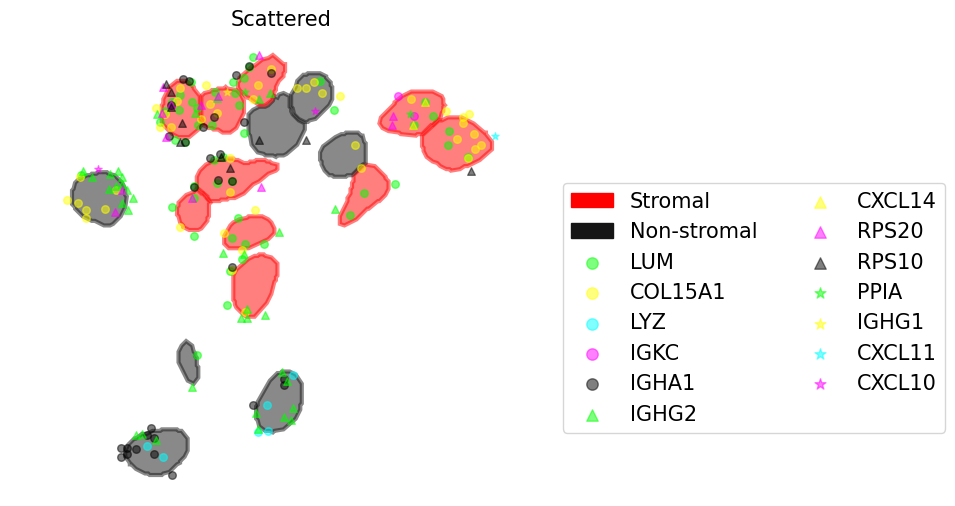

In [ ]:
cell_type_colors = {'Stromal': '#FF0000', 'Non-stromal': '#151515'}

fig, ax = plt.subplots(1, 1, figsize=(7, 6))
shape_by_type = {}
for label in neighborhood:
    cell_shape = sub_cell[sub_cell['label'] == label][['x', 'y']].values
    color = cell_type_colors[cells_properties_df[cells_properties_df['label'] == label]['cell_types'].values[0]]
    polygon = Polygon(cell_shape, closed=True, edgecolor=color, facecolor=color, lw=3, alpha=0.5)
    ax.add_patch(polygon)
    if cells_properties_df[cells_properties_df['label'] == label]['cell_types'].values[0] not in shape_by_type.keys():
        shape_by_type[cells_properties_df[cells_properties_df['label'] == label]['cell_types'].values[0]] = []
    shape_by_type[cells_properties_df[cells_properties_df['label'] == label]['cell_types'].values[0]].append(polygon)


colors = ['#00ff00', '#ffff00', '#00ffff', '#ff00ff', '#000000']
for i, gene in enumerate(marker_set1):
    to_plot = sub_transcripts[sub_transcripts['gene'] == gene]
    if len(to_plot) > 0:
        x = to_plot['col']
        y = to_plot['row']
        ax.scatter(x, y, color=colors[i], s=30, alpha=0.5, label=gene)

for i, gene in enumerate(marker_set2):
    to_plot = sub_transcripts[sub_transcripts['gene'] == gene]
    if len(to_plot) > 0:
        x = to_plot['col']
        y = to_plot['row']
        ax.scatter(x, y, color=colors[i], s=30, alpha=0.5, marker='^', label=gene)

for i, gene in enumerate(marker_set3):
    to_plot = sub_transcripts[sub_transcripts['gene'] == gene]
    if len(to_plot) > 0:
        x = to_plot['col']
        y = to_plot['row']
        ax.scatter(x, y, color=colors[i], s=30, alpha=0.5, marker='*', label=gene)
ax.set_title(f'Scattered', fontsize=15)
legend_patches = [mpatches.Patch(color=color, label=cls) for cls, color in cell_type_colors.items()]
ax.legend(handles=legend_patches+ax.get_legend_handles_labels()[0], loc='upper left', bbox_to_anchor=(1,0.7), fontsize=15, markerscale=1.5, ncol=2)
ax.axis('equal')
ax.axis('off')
# plt.tight_layout()
plt.savefig(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA+_83-1\00_analysis\sub_graphs_395_scattered.png', dpi=300, bbox_inches='tight')
plt.show()

# 174c

In [ ]:
cells_properties_df = pd.read_csv(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA-_174-1\00_analysis\expression.csv', index_col=0)
cells_properties_df.reset_index(inplace=True)

In [ ]:
k = 5
adj_matrix = kneighbors_graph(cells_properties_df[['row','col']].values.astype('float'), n_neighbors=k, mode='distance', include_self=False)

In [ ]:
n_components, labels = connected_components(adj_matrix, directed=False)

In [ ]:
row,col = adj_matrix.nonzero()
edges = np.column_stack((row,col))
unique_edges = edges[edges[:, 0] < edges[:, 1]]

In [ ]:
with open(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA-_174-1\00_analysis\unique_edges.pkl', 'wb') as f:
    pickle.dump(unique_edges, f)

In [ ]:
boundary = pd.read_csv(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA-_174-1\00_analysis\cell_boundary.csv', index_col=0)
detected_dots = pd.read_csv(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA-_174-1\00_analysis\detected_dots_filtered.csv', index_col=0)

In [ ]:
top_10_percent_threshold = 1.98046875
cell_types = ['Stromal' if cells_properties_df.loc[cell, 'LUM'] > top_10_percent_threshold else 'Non-stromal' for cell in cells_properties_df.index]
cells_properties_df['cell_types'] = cell_types

In [ ]:
cells_properties_df['cell_types'].value_counts()

In [9]:
cells = cells_properties_df[cells_properties_df['cell_types'] == 'Stromal']
cells_idx = cells.index.tolist()

In [10]:
cells_properties_df.to_csv(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA-_174-1\00_analysis\cells_properties_df_annotated.csv', index=False)

In [11]:
cells_properties_df = pd.read_csv(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA-_174-1\00_analysis\cells_properties_df_annotated.csv')

In [25]:
sub_graphs_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, cells_properties_df, unique_edges) for cell in cells_idx)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.11970901489257812s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]

In [26]:
with open(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA-_174-1\00_analysis\sub_graphs.pkl', 'wb') as f:
    pickle.dump(sub_graphs_l, f)

In [ ]:
cells_properties_df = pd.read_csv(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA-_174-1\00_analysis\expression.csv', index_col=0)
cells_properties_df.reset_index(inplace=True)

In [ ]:
k = 5
adj_matrix = kneighbors_graph(cells_properties_df[['row','col']].values.astype('float'), n_neighbors=k, mode='distance', include_self=False)

In [ ]:
n_components, labels = connected_components(adj_matrix, directed=False)

In [ ]:
row,col = adj_matrix.nonzero()
edges = np.column_stack((row,col))
unique_edges = edges[edges[:, 0] < edges[:, 1]]

In [ ]:
with open(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA-_174-1\00_analysis\unique_edges.pkl', 'wb') as f:
    pickle.dump(unique_edges, f)

In [ ]:
boundary = pd.read_csv(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA-_174-1\00_analysis\cell_boundary.csv', index_col=0)
detected_dots = pd.read_csv(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA-_174-1\00_analysis\detected_dots_filtered.csv', index_col=0)

In [ ]:
top_10_percent_threshold = 1.98046875
cell_types = ['Stromal' if cells_properties_df.loc[cell, 'LUM'] > top_10_percent_threshold else 'Non-stromal' for cell in cells_properties_df.index]
cells_properties_df['cell_types'] = cell_types

In [ ]:
cells = cells_properties_df[cells_properties_df['cell_types'] == 'Stromal']
cells_idx = cells.index.tolist()

In [ ]:
cells_properties_df.to_csv(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA-_174-1\00_analysis\cells_properties_df_annotated.csv', index=False)

In [ ]:
cells_properties_df = pd.read_csv(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA-_174-1\00_analysis\cells_properties_df_annotated.csv')

In [ ]:
sub_graphs_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, cells_properties_df, unique_edges) for cell in cells_idx)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.11970901489257812s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]

In [ ]:
with open(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA-_174-1\00_analysis\sub_graphs.pkl', 'wb') as f:
    pickle.dump(sub_graphs_l, f)

In [ ]:
# Example neighborhood
# inside infiltrate: 174-1, 856, peri-infiltrate: 174-1, 772, interstitial: 174-1, 223

In [15]:
sub_graphs_l = pickle.load(open(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA-_174-1\00_analysis\sub_graphs.pkl', 'rb'))

In [16]:
cell_boundary = pd.read_csv(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA-_174-1\00_analysis\cell_boundary.csv')

In [39]:
graph = sub_graphs_l[223]
neighborhood = np.unique(np.array(graph))
sub_cell = cell_boundary[cell_boundary['label'].isin(neighborhood)]
sub_transcripts = detected_dots[detected_dots['label'].isin(neighborhood)]

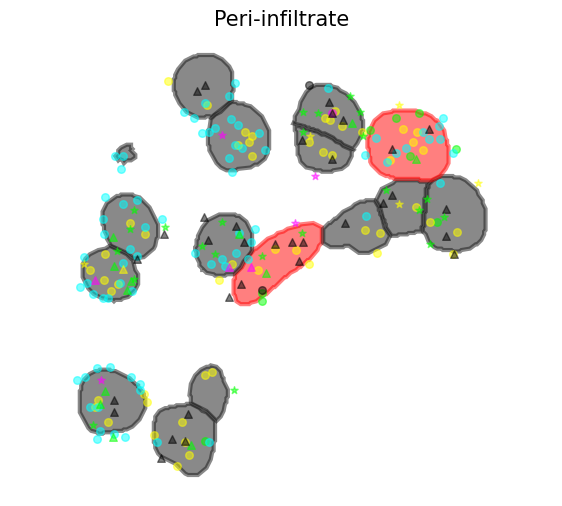

In [40]:
cell_type_colors = {'Stromal': '#FF0000', 'Non-stromal': '#151515'}

fig, ax = plt.subplots(1, 1, figsize=(7, 6))
shape_by_type = {}
for label in neighborhood:
    cell_shape = sub_cell[sub_cell['label'] == label][['x', 'y']].values
    color = cell_type_colors[cells_properties_df[cells_properties_df['label'] == label]['cell_types'].values[0]]
    polygon = Polygon(cell_shape, closed=True, edgecolor=color, facecolor=color, lw=3, alpha=0.5)
    ax.add_patch(polygon)
    if cells_properties_df[cells_properties_df['label'] == label]['cell_types'].values[0] not in shape_by_type.keys():
        shape_by_type[cells_properties_df[cells_properties_df['label'] == label]['cell_types'].values[0]] = []
    shape_by_type[cells_properties_df[cells_properties_df['label'] == label]['cell_types'].values[0]].append(polygon)


colors = ['#00ff00', '#ffff00', '#00ffff', '#ff00ff', '#000000']
for i, gene in enumerate(marker_set1):
    to_plot = sub_transcripts[sub_transcripts['gene'] == gene]
    if len(to_plot) > 0:
        x = to_plot['col']
        y = to_plot['row']
        ax.scatter(x, y, color=colors[i], s=30, alpha=0.5, label=gene)

for i, gene in enumerate(marker_set2):
    to_plot = sub_transcripts[sub_transcripts['gene'] == gene]
    if len(to_plot) > 0:
        x = to_plot['col']
        y = to_plot['row']
        ax.scatter(x, y, color=colors[i], s=30, alpha=0.5, marker='^', label=gene)

for i, gene in enumerate(marker_set3):
    to_plot = sub_transcripts[sub_transcripts['gene'] == gene]
    if len(to_plot) > 0:
        x = to_plot['col']
        y = to_plot['row']
        ax.scatter(x, y, color=colors[i], s=30, alpha=0.5, marker='*', label=gene)
ax.set_title('Peri-infiltrate', fontsize=15)
legend_patches = [mpatches.Patch(color=color, label=cls) for cls, color in cell_type_colors.items()]
# ax.legend(handles=legend_patches+ax.get_legend_handles_labels()[0], loc='upper left', bbox_to_anchor=(1,0.7), fontsize=15, markerscale=1.5, ncol=1)
ax.axis('equal')
ax.axis('off')
# plt.tight_layout()
plt.savefig(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA-_174-1\00_analysis\sub_graphs_223.png', dpi=300, bbox_inches='tight')
plt.show()

In [32]:
infiltrate_boundary = pd.read_csv(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA-_174-1\00_analysis\infiltrate_boundary.csv', index_col=0)

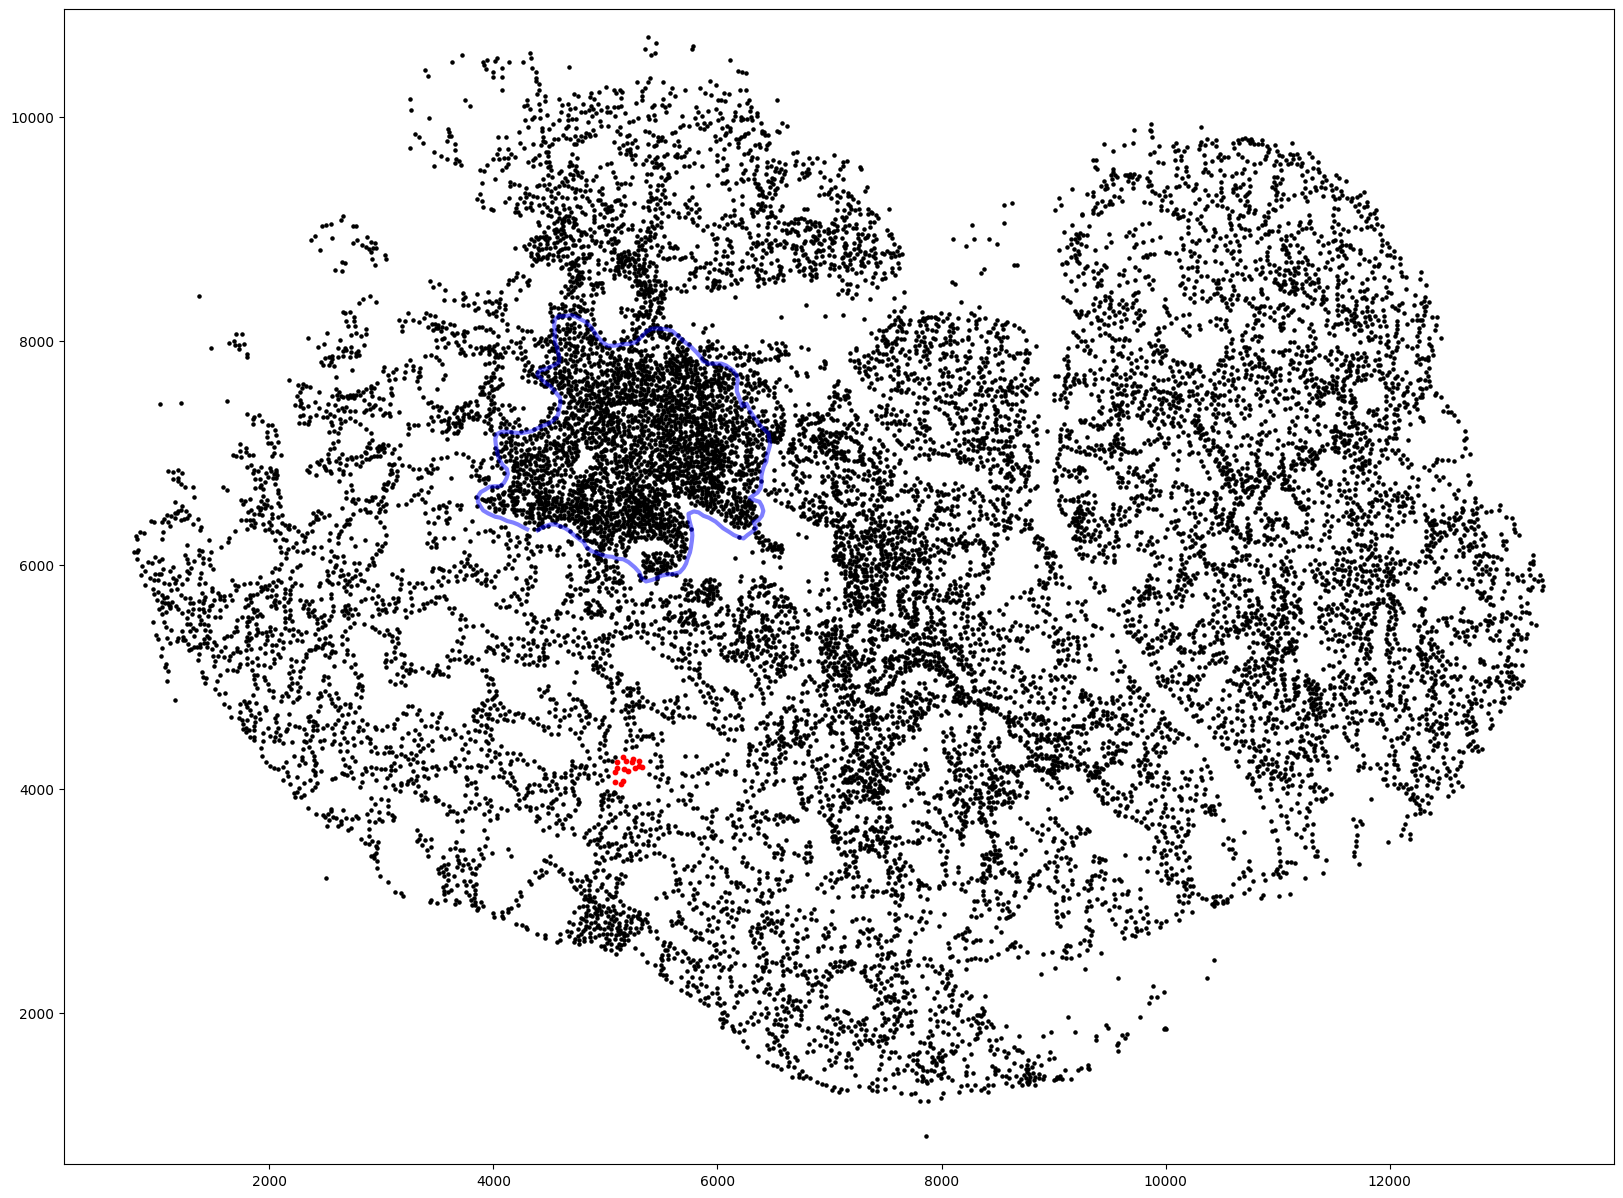

In [41]:
with rc_context({'figure.figsize': (20, 15)}):
    fig, ax = plt.subplots(1, 1)
    ax.scatter(cells_properties_df['col'], cells_properties_df['row'], color='black', s=5)
    sub_properties_df = cells_properties_df[cells_properties_df['label'].isin(neighborhood)]
    ax.scatter(sub_properties_df['col'], sub_properties_df['row'], color='red', s=10)
    ax.plot(infiltrate_boundary['col'], infiltrate_boundary['row'], c='blue', alpha=0.5, linewidth=3)
    ax.axis('equal')
    plt.savefig(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA-_174-1\00_analysis\sub_graphs_223_positions.png', dpi=300, bbox_inches='tight')
    plt.show()

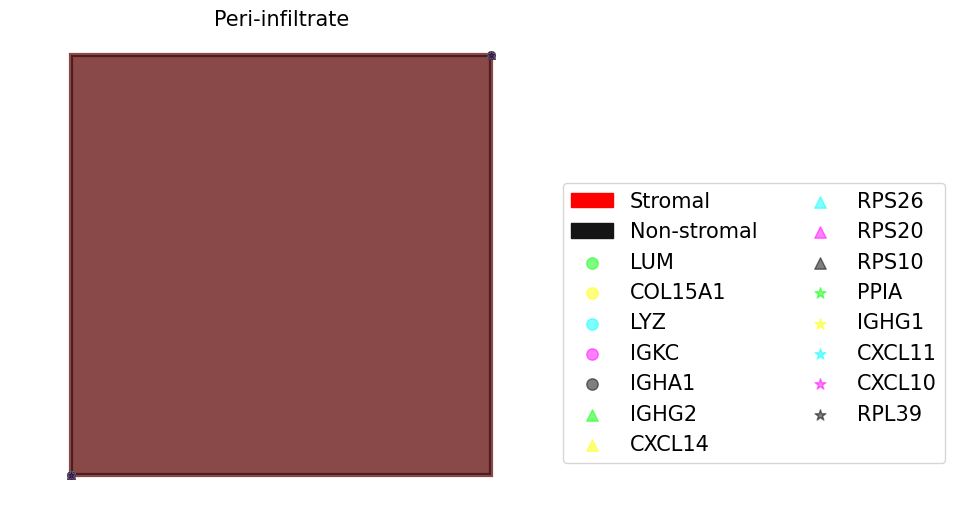

In [46]:
# plot legend
cell_type_colors = {'Stromal': '#FF0000', 'Non-stromal': '#151515'}

fig, ax = plt.subplots(1, 1, figsize=(7, 6))
shape_by_type = {}
for label in cell_type_colors.keys():
    cell_shape = np.array([[0,0], [1,0], [1,1], [0,1]])  # Dummy shape for legend
    color = cell_type_colors[label]
    polygon = Polygon(cell_shape, closed=True, edgecolor=color, facecolor=color, lw=3, alpha=0.5)
    ax.add_patch(polygon)
    # if cells_properties_df[cells_properties_df['label'] == label]['cell_types'].values[0] not in shape_by_type.keys():
    #     shape_by_type[cells_properties_df[cells_properties_df['label'] == label]['cell_types'].values[0]] = []
    # shape_by_type[cells_properties_df[cells_properties_df['label'] == label]['cell_types'].values[0]].append(polygon)


colors = ['#00ff00', '#ffff00', '#00ffff', '#ff00ff', '#000000']
for i, gene in enumerate(marker_set1):
    to_plot = marker_set1
    if len(to_plot) > 0:
        x = [0, 1]  # Dummy x-coordinates for legend
        y = [0,1]
        ax.scatter(x, y, color=colors[i], s=30, alpha=0.5, label=gene)

for i, gene in enumerate(marker_set2):
    to_plot = marker_set2
    if len(to_plot) > 0:
        x = [0,1]
        y = [0,1]
        ax.scatter(x, y, color=colors[i], s=30, alpha=0.5, marker='^', label=gene)

for i, gene in enumerate(marker_set3):
    to_plot = marker_set3
    if len(to_plot) > 0:
        x = [0,1]
        y = [0,1]
        ax.scatter(x, y, color=colors[i], s=30, alpha=0.5, marker='*', label=gene)
ax.set_title('Peri-infiltrate', fontsize=15)
legend_patches = [mpatches.Patch(color=color, label=cls) for cls, color in cell_type_colors.items()]
ax.legend(handles=legend_patches+ax.get_legend_handles_labels()[0], loc='upper left', bbox_to_anchor=(1,0.7), fontsize=15, markerscale=1.5, ncol=2)
ax.axis('equal')
ax.axis('off')
# plt.tight_layout()
plt.savefig(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA-_174-1\00_analysis\scatter_plot_legend.png', dpi=300, bbox_inches='tight')
plt.show()

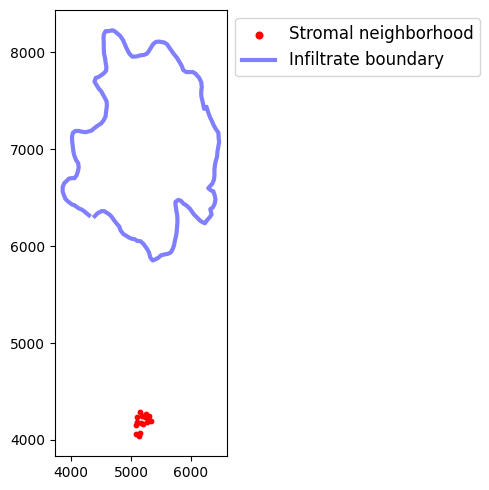

In [50]:
# neighborhood position scatter plot
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.scatter(sub_properties_df['col'], sub_properties_df['row'], color='red', s=10, label='Stromal neighborhood')
ax.plot(infiltrate_boundary['col'], infiltrate_boundary['row'], c='blue', alpha=0.5, linewidth=3, label='Infiltrate boundary')
ax.legend(loc='upper left', fontsize=12, bbox_to_anchor=(1, 1), markerscale=1.5)
plt.tight_layout()
plt.savefig(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA-_174-1\00_analysis\neighborhood_position_legend.png', dpi=300, bbox_inches='tight')
plt.show()

# 84a

In [61]:
cells_properties_df = pd.read_csv(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA+_84-1\00_analysis\expression.csv', index_col=0)
cells_properties_df.reset_index(inplace=True)

In [62]:
cells_properties_df

,label,label.1,area,row,col,LYZ,IGHA1,IGHG2,CXCL14,LUM,...,GAPDH,IDO2,TGFB1,CXCL10,TNFAIP3,IFI44,BIRC3,ADRA2A,RGS16,UBD
0,1,1,1033,963.207164,18451.999032,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,2,1343,977.313477,18479.977662,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,3,1888,977.950212,18358.344809,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,4,1495,974.753846,18409.632107,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,5,1474,984.126866,18530.097015,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65857,73787,73787,807,15671.682776,11751.697646,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
65858,73788,73788,885,15670.092655,12124.745763,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0
65859,73789,73789,585,15677.104274,12084.755556,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
65860,73790,73790,1630,15715.346626,12108.753374,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [63]:
k = 5
adj_matrix = kneighbors_graph(cells_properties_df[['row','col']].values.astype('float'), n_neighbors=k, mode='distance', include_self=False)

In [64]:
n_components, labels = connected_components(adj_matrix, directed=False)

In [65]:
row,col = adj_matrix.nonzero()
edges = np.column_stack((row,col))
unique_edges = edges[edges[:, 0] < edges[:, 1]]

In [66]:
with open(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA+_84-1\00_analysis\unique_edges.pkl', 'wb') as f:
    pickle.dump(unique_edges, f)

In [67]:
boundary = pd.read_csv(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA+_84-1\00_analysis\cell_boundary.csv', index_col=0)
detected_dots = pd.read_csv(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA+_83-1\00_analysis\detected_dots_filtered.csv', index_col=0)

In [68]:
top_10_percent_threshold = cells_properties_df['LUM'].quantile(0.84)
# cell_types = ['Stromal' if cells_properties_df.loc[cell, 'LUM'] > top_10_percent_threshold else 'Non-stromal' for cell in cells_properties_df.index]
# cells_properties_df['cell_types'] = cell_types

In [69]:
top_10_percent_threshold

np.float64(1.0)

In [70]:
# top_10_percent_threshold = 1.98046875
cell_types = ['Stromal' if cells_properties_df.loc[cell, 'LUM'] > top_10_percent_threshold else 'Non-stromal' for cell in cells_properties_df.index]
cells_properties_df['cell_types'] = cell_types

In [71]:
cells = cells_properties_df[cells_properties_df['cell_types'] == 'Stromal']
cells_idx = cells.index.tolist()

In [72]:
cells_properties_df.to_csv(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA+_84-1\00_analysis\cells_properties_df_annotated.csv', index=False)

In [73]:
cells_properties_df = pd.read_csv(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA+_84-1\00_analysis\cells_properties_df_annotated.csv')

In [74]:
sub_graphs_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, cells_properties_df, unique_edges) for cell in cells_idx)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    4.2s
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    5.6s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    5.6s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    5.7s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    5.7s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    6.1s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    6.2s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    6.2s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    6.2s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    6.2s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    6.2s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    6.4s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    6.5s
[Parallel(n_jobs=-3)]: Done  14 tasks      | elapsed:    6.5s
[Parallel(n_jobs=-3)]: Done  15 tasks      | elapsed:  

In [75]:
with open(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA+_84-1\00_analysis\sub_graphs.pkl', 'wb') as f:
    pickle.dump(sub_graphs_l, f)

In [76]:
# filter by remaining tissue mask

In [77]:
import tifffile
from tqdm import tqdm

In [78]:
mask = tifffile.imread(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA+_84-1\00_analysis\remaining_tissue_mask.tif')
mask = mask.astype(bool)

In [79]:
in_mask_mean = []
for sub_graph in tqdm(sub_graphs_l):
    cells_in_subgraph = np.unique(sub_graph)
    cell_pos_sub = cells_properties_df[cells_properties_df['label'].isin(cells_in_subgraph)][['row', 'col']].copy()
    cell_pos_sub['row'] = cell_pos_sub['row'].astype(int)
    cell_pos_sub['col'] = cell_pos_sub['col'].astype(int)
    in_mask = mask[cell_pos_sub['row'], cell_pos_sub['col']]
    in_mask_mean.append(np.mean(in_mask))

 28%|██▊       | 1194/4328 [00:01<00:04, 749.93it/s]c:\Users\zfang38\AppData\Local\anaconda3\envs\scanpy2\lib\site-packages\numpy\_core\fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\zfang38\AppData\Local\anaconda3\envs\scanpy2\lib\site-packages\numpy\_core\_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
 97%|█████████▋| 4177/4328 [00:05<00:00, 751.15it/s]c:\Users\zfang38\AppData\Local\anaconda3\envs\scanpy2\lib\site-packages\numpy\_core\fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\zfang38\AppData\Local\anaconda3\envs\scanpy2\lib\site-packages\numpy\_core\_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
 98%|█████████▊| 4253/4328 [00:05<00:00, 751.38it/s]c:\Users\zfang38\AppData\Local\anaconda3\envs\scanpy2\lib\site-p

In [80]:
# fill any NaN values with 0
in_mask_mean = np.nan_to_num(in_mask_mean, nan=0)

In [81]:
# keep subgraphs where in_mask_mean == 1
sub_graphs_l = [sub_graph for sub_graph, mean in zip(sub_graphs_l, in_mask_mean) if mean == 1]

In [82]:
len(sub_graphs_l)

2556

In [83]:
with open(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA+_84-1\00_analysis\sub_graphs_filtered.pkl', 'wb') as f:
    pickle.dump(sub_graphs_l, f)

# 7202a

In [84]:
cells_properties_df = pd.read_csv(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA-_7202-1\00_analysis\expression.csv', index_col=0)
cells_properties_df.reset_index(inplace=True)

In [85]:
k = 5
adj_matrix = kneighbors_graph(cells_properties_df[['row','col']].values.astype('float'), n_neighbors=k, mode='distance', include_self=False)

In [86]:
n_components, labels = connected_components(adj_matrix, directed=False)

In [87]:
row,col = adj_matrix.nonzero()
edges = np.column_stack((row,col))
unique_edges = edges[edges[:, 0] < edges[:, 1]]

In [88]:
with open(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA-_7202-1\00_analysis\unique_edges.pkl', 'wb') as f:
    pickle.dump(unique_edges, f)

In [89]:
boundary = pd.read_csv(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA-_7202-1\00_analysis\cell_boundary.csv', index_col=0)
detected_dots = pd.read_csv(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA-_7202-1\00_analysis\detected_dots_filtered.csv', index_col=0)

In [90]:
top_10_percent_threshold = cells_properties_df['LUM'].quantile(0.84)
# cell_types = ['Stromal' if cells_properties_df.loc[cell, 'LUM'] > top_10_percent_threshold else 'Non-stromal' for cell in cells_properties_df.index]
# cells_properties_df['cell_types'] = cell_types

In [91]:
top_10_percent_threshold

np.float64(1.0)

In [92]:
# top_10_percent_threshold = 1.98046875
cell_types = ['Stromal' if cells_properties_df.loc[cell, 'LUM'] > top_10_percent_threshold else 'Non-stromal' for cell in cells_properties_df.index]
cells_properties_df['cell_types'] = cell_types

In [93]:
cells = cells_properties_df[cells_properties_df['cell_types'] == 'Stromal']
cells_idx = cells.index.tolist()

In [94]:
cells_properties_df.to_csv(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA-_7202-1\00_analysis\cells_properties_df_annotated.csv', index=False)

In [95]:
cells_properties_df = pd.read_csv(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA-_7202-1\00_analysis\cells_properties_df_annotated.csv')

In [96]:
sub_graphs_l = Parallel(n_jobs=-3, verbose=100)(delayed(sub_graphs)(cell, cells_properties_df, unique_edges) for cell in cells_idx)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.17544841766357422s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]

In [97]:
with open(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA-_7202-1\00_analysis\sub_graphs.pkl', 'wb') as f:
    pickle.dump(sub_graphs_l, f)

In [98]:
# filter by remaining tissue mask

In [99]:
import tifffile
from tqdm import tqdm

In [100]:
mask = tifffile.imread(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA-_7202-1\00_analysis\remaining_tissue_mask.tif')
mask = mask.astype(bool)

In [101]:
in_mask_mean = []
for sub_graph in tqdm(sub_graphs_l):
    cells_in_subgraph = np.unique(sub_graph)
    cell_pos_sub = cells_properties_df[cells_properties_df['label'].isin(cells_in_subgraph)][['row', 'col']].copy()
    cell_pos_sub['row'] = cell_pos_sub['row'].astype(int)
    cell_pos_sub['col'] = cell_pos_sub['col'].astype(int)
    in_mask = mask[cell_pos_sub['row'], cell_pos_sub['col']]
    in_mask_mean.append(np.mean(in_mask))

  7%|▋         | 95/1397 [00:00<00:01, 949.26it/s]c:\Users\zfang38\AppData\Local\anaconda3\envs\scanpy2\lib\site-packages\numpy\_core\fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\zfang38\AppData\Local\anaconda3\envs\scanpy2\lib\site-packages\numpy\_core\_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
 75%|███████▌  | 1049/1397 [00:01<00:00, 1066.66it/s]c:\Users\zfang38\AppData\Local\anaconda3\envs\scanpy2\lib\site-packages\numpy\_core\fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\zfang38\AppData\Local\anaconda3\envs\scanpy2\lib\site-packages\numpy\_core\_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
 83%|████████▎ | 1158/1397 [00:01<00:00, 1071.93it/s]c:\Users\zfang38\AppData\Local\anaconda3\envs\scanpy2\lib\site-p

In [102]:
# fill any NaN values with 0
in_mask_mean = np.nan_to_num(in_mask_mean, nan=0)

In [103]:
# keep subgraphs where in_mask_mean == 1
sub_graphs_l = [sub_graph for sub_graph, mean in zip(sub_graphs_l, in_mask_mean) if mean == 1]

In [104]:
len(sub_graphs_l)

839

In [105]:
with open(r'Y:\coskun-lab2\Zhou\12_MSG\20240918_xenium_hcr\SSA-_7202-1\00_analysis\sub_graphs_filtered.pkl', 'wb') as f:
    pickle.dump(sub_graphs_l, f)